In [ ]:
import marimo as mo

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve
from log_energy_epjst_package.models.white_noise import white_noise
from log_energy_epjst_package.models.brownian_motion import brownian_motion
from MRW_LAMBDA_ESTIMATOR.surrogate_mrw_lambda import generate_mrw
from signal_analysis import analyze_signal, psi_haar_smooth
from toy_models.model5_lognormal_cascade import generate as generate_lognormal_cascade
from toy_models.model8_fbm import fbm_daviesharte as generate_fbm

def covariance_fft(x):
    x = x - np.mean(x)
    c = fftconvolve(x, x[::-1], mode='full')
    c = c[c.size // 2:]
    return c / c[0]

def compare_signals(signals, **analysis_kwargs):
    results = {}
    for name, signal in signals.items():
        results[name] = analyze_signal(signal, **analysis_kwargs)
    return results

def plot_signals(results):
    """Plot the original signals (treated as log-price)."""
    fig, axes = plt.subplots(len(results), 1, figsize=(10, 4 * len(results)), sharex=True)
    if len(results) == 1:
        axes = [axes]
    for ax, (name, output) in zip(axes, results.items()):
        ax.plot(output['signal'])
        ax.set_title(f'{name}: Signal')
        ax.set_ylabel('Value')
    plt.xlabel('Time')
    plt.tight_layout()
    plt.show()

def plot_volatility_walks(results, scale_idx=3):
    """Plot centered log-volatility walks for each signal."""
    fig, axes = plt.subplots(len(results), 1, figsize=(10, 4 * len(results)), sharex=True)
    if len(results) == 1:
        axes = [axes]
    for ax, (name, output) in zip(axes, results.items()):
        w_a = output['log_vol_series'][scale_idx]
        w_a_centered = w_a - np.mean(w_a)
        v_a = np.cumsum(w_a_centered)
        ax.plot(v_a)
        ax.set_title(f"{name}: Centered Log-Volatility Walk (Scale {output['scales'][scale_idx]})")
        ax.set_ylabel('Walk Value')
    plt.xlabel('Time')
    plt.tight_layout()
    plt.show()

def plot_autocorrelations(results, scale_idx=3, max_lag=500):
    """Plot autocorrelations of returns and log-volatility."""
    fig, axes = plt.subplots(len(results), 2, figsize=(12, 4 * len(results)))
    if len(results) == 1:
        axes = axes.reshape(1, -1)
    for i, (name, output) in enumerate(results.items()):
        signal = output['signal']
        ret = np.diff(signal)
        ret_ac = covariance_fft(ret)
        w_a = output['log_vol_series'][scale_idx]
        w_ac = covariance_fft(w_a)
        axes[i, 0].plot(ret_ac[:max_lag + 1])
        axes[i, 0].set_title(f'{name}: Return Autocorrelation')
        axes[i, 0].set_xlabel('Lag')
        axes[i, 0].set_ylabel('Autocorrelation')
        axes[i, 1].plot(w_ac[:max_lag + 1])
        axes[i, 1].set_title(f"{name}: Log-Volatility Autocorrelation (Scale {output['scales'][scale_idx]})")
        axes[i, 1].set_xlabel('Lag')
        axes[i, 1].set_ylabel('Autocorrelation')
    plt.tight_layout()
    plt.show()

def plot_mi_maps(results, max_time_lag,negative=False):
    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5), sharey=True)
    if len(results) == 1:
        axes = [axes]
    for ax, (name, output) in zip(axes, results.items()):
        im = ax.imshow(output['mi_map'], aspect='auto', origin='upper', extent=[-max_time_lag, max_time_lag, output['scales'][-1], output['scales'][0]])
        ax.set_title(name)
        ax.set_xlabel('Time lag')
        ax.set_ylabel('Scale')
        fig.colorbar(im, ax=ax, label='Mutual Information')
    plt.tight_layout()
    plt.show()
    if not negative:
        for key in results.keys():
            mi_normalized = []
            for i, I in enumerate(results[key]['mi_map']):
                mi_normalized.append(I / np.max(I))
            results[key]['mi_map_normalized'] = mi_normalized
    else:
        for key in results.keys():
            mi_normalized = []
            for i, I in enumerate(results[key]['mi_map']):
                mi_normalized.append((I+np.abs(np.min(I))) / np.abs(np.max(I)-np.min(I)))
            results[key]['mi_map_normalized'] = mi_normalized
    fig, axes = plt.subplots(1, len(results), figsize=(6 * len(results), 5), sharey=True)
    if len(results) == 1:
        axes = [axes]
    for ax, (name, output) in zip(axes, results.items()):
        im = ax.imshow(output['mi_map_normalized'], aspect='auto', origin='upper' , extent=[-max_time_lag, max_time_lag, output['scales'][-1], output['scales'][0]])
        ax.set_title(name)
        ax.set_xlabel('Time lag')
        ax.set_ylabel('Scale')
        fig.colorbar(im, ax=ax, label='Mutual Information normalized')
    plt.tight_layout()
    plt.show()

# performance comparison
multiprocessing of a single dt,s instance vs computing single dt instance and MI for all s is processed internally by scikit

640533


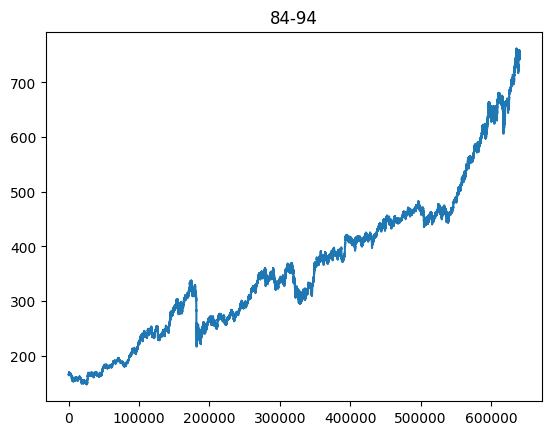

In [ ]:
import pandas as pd

DATA_PATH = "SandP_log2min.dat"   # one value per row

# Try reading with header; if no header, fallback
try:
    df_snp = pd.read_csv(DATA_PATH)
    if df_snp.shape[1] == 1:
        df_snp.columns = ['log_price']
except:
    df_snp = pd.read_csv(DATA_PATH, header=None)
    df_snp.columns = ['log_price']

df_snp = df_snp.dropna().reset_index(drop=True)

# Log-price
df_snp['price'] = 0.01*np.exp(df_snp['log_price'])

print(len(df_snp))
df_snp.head()

plt.plot(0.01*np.exp(df_snp["log_price"]))
plt.title("84-94")
plt.show()

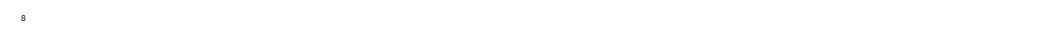

In [ ]:
import multiprocess as mp
mp.cpu_count

## S&P
signal length 30000

In [ ]:
def analyse_SandP(df,batched):
    log_price = np.array(df['log_price'].values)

    n_samples = 30000
    scales = np.logspace(np.log10(4), np.log10(2000), 25)
    signals = {
        'S&P500': log_price[:n_samples]
    }
    results = compare_signals(signals, scales=scales, wavelet=psi_haar_smooth, max_level=8, window=50, ref_idx=0, max_time_lag=400, use_parallel=True, n_jobs=8,batched=batched)

    for name, output in results.items():
        print(f"{name}: log_vol_series shape = {output['log_vol_series'].shape}, mi_map shape = {output['mi_map'].shape}")
    plot_signals(results)
    plot_volatility_walks(results, scale_idx=3)
    plot_autocorrelations(results, scale_idx=3, max_lag=500)
    plot_mi_maps(results, max_time_lag=400)

    return results


S&P500: log_vol_series shape = (25, 30000), mi_map shape = (25, 801)


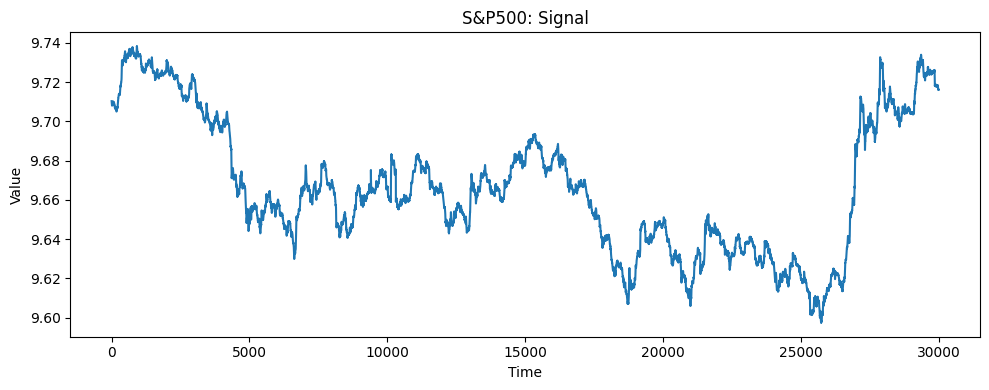

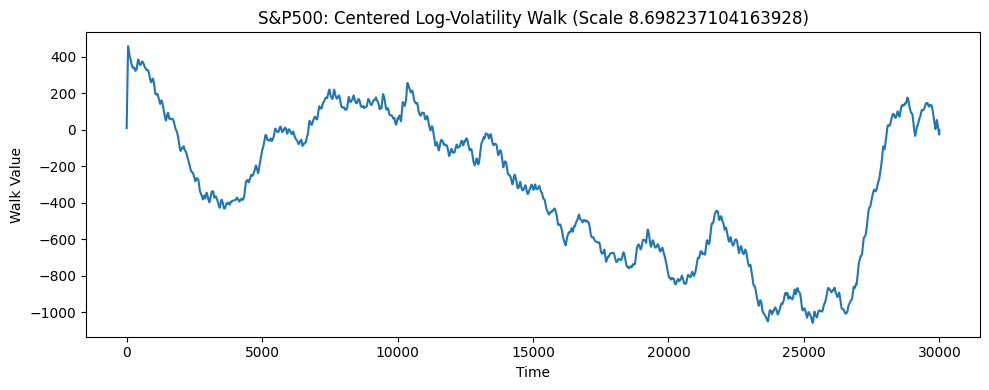

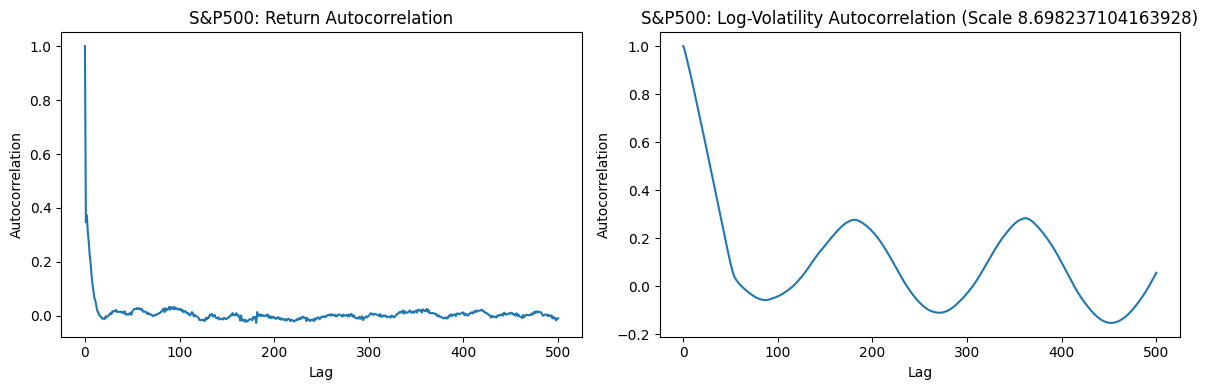

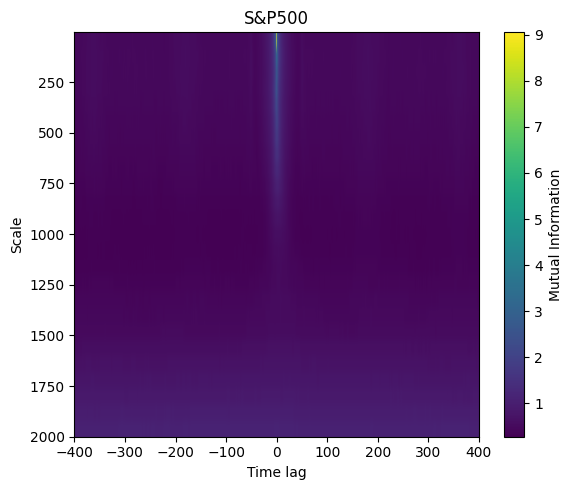

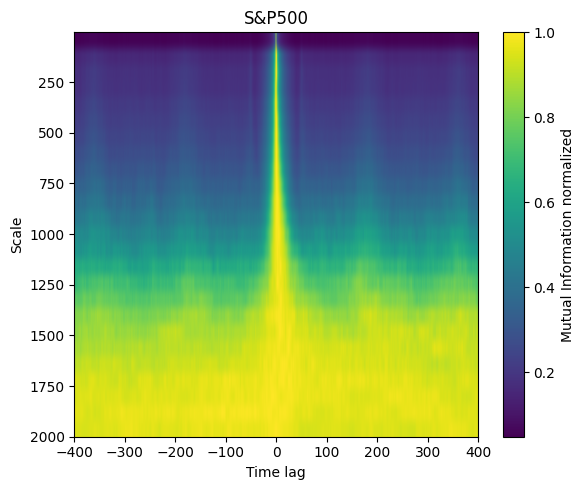

In [ ]:
results_snp = analyse_SandP(df_snp,batched=True)

S&P500: log_vol_series shape = (25, 30000), mi_map shape = (25, 801)


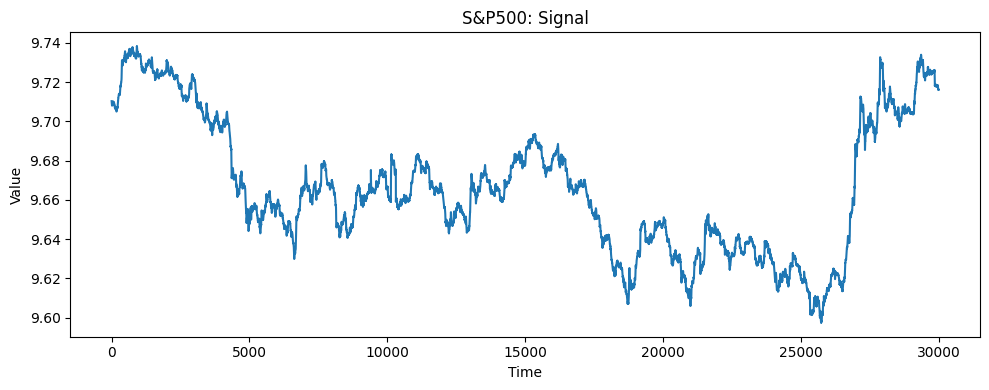

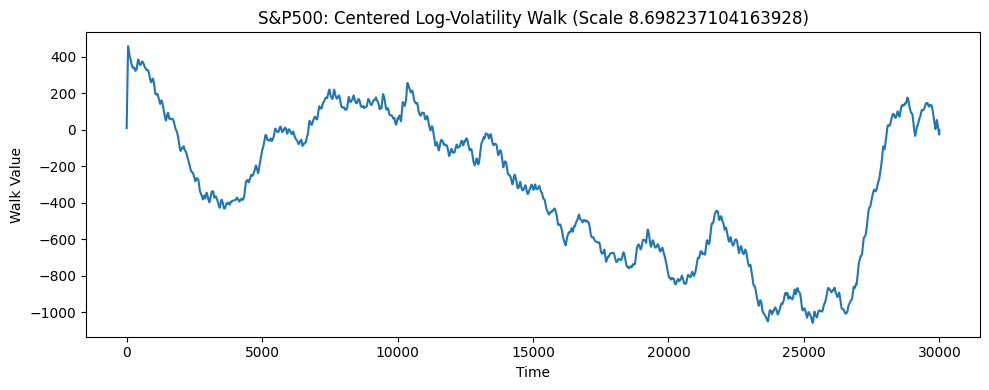

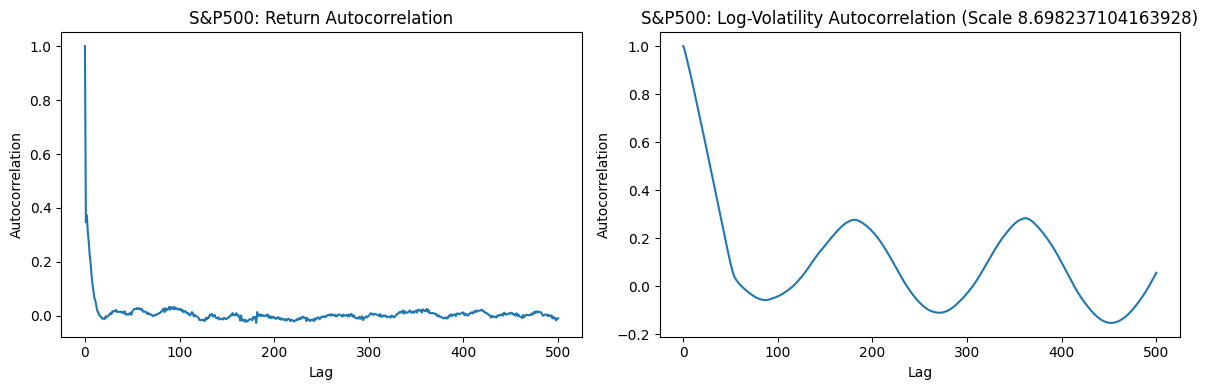

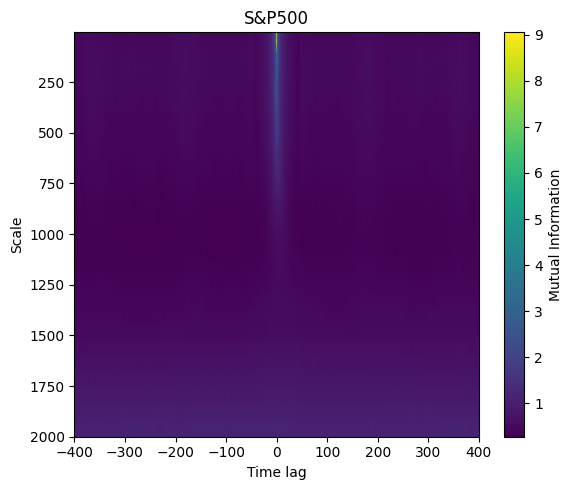

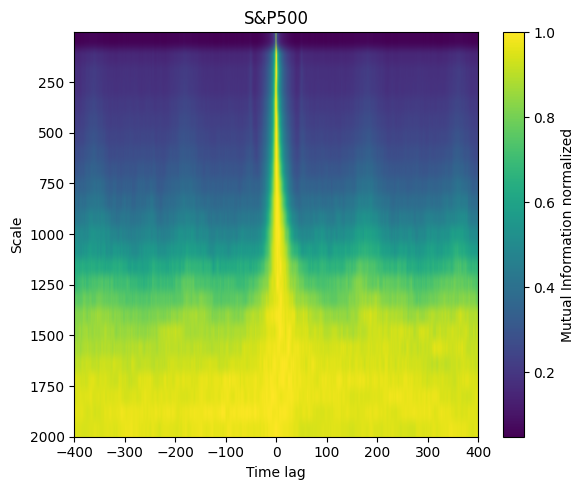

In [ ]:
results_snp_legacy = analyse_SandP(df_snp,batched=False)

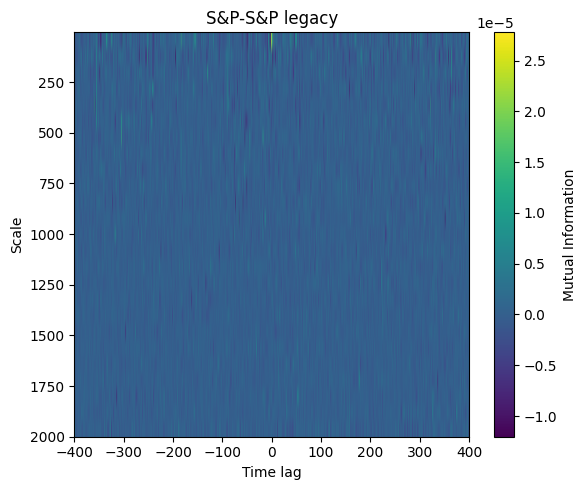

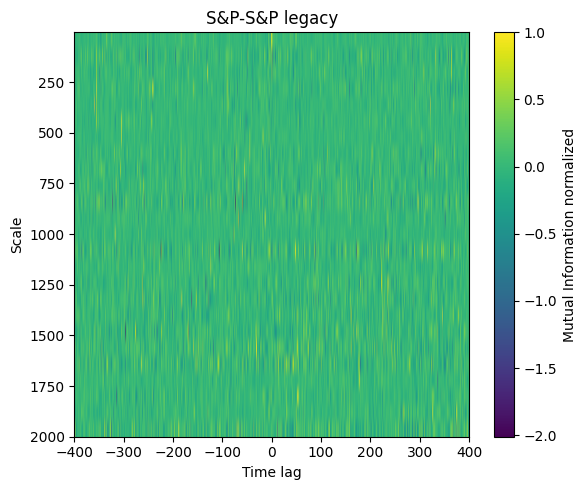

In [ ]:
results_method_comp = {}
results_method_comp["S&P-S&P legacy"] = {}
results_method_comp["S&P-S&P legacy"]["scales"] = results_snp["S&P500"]["scales"]
results_method_comp["S&P-S&P legacy"]["mi_map"] = results_snp["S&P500"]["mi_map"] - results_snp_legacy["S&P500"]["mi_map"]

plot_mi_maps(results_method_comp,400)

the speedup is negligible 26 min 50' vs 27 min 30'

## S&P
10 batches 30000

In [ ]:
window_size = 30000
num_windows = 20

windows = [
    df_snp.iloc[i*window_size : (i+1)*window_size].reset_index(drop=True)
    for i in range(num_windows)
]
for w in windows[::2]:
    plt.plot(w["price"])
    plt.show()

In [ ]:
SnP_results_batch = []
for i,window in enumerate(windows[::2]):
    if i==0:
        continue
    result_batch = analyse_SandP(df=window)
    np.save(f"mi_map_snp_{2*i*30000}-{(2*i+1)*30000}.npy",result_batch)
    SnP_results_batch.append(result_batch)

In [ ]:
np.save("mi_map_snp_all.npy",SnP_results_batch)

In [ ]:
SnP_results_batch_2 = []
for _i,_window in enumerate(windows[1::2]):
    _result_batch = analyse_SandP(df=_window)
    np.save(f"mi_map_snp_{(2*_i+1)*30000}-{(2*_i+2)*30000}.npy",_result_batch)
    SnP_results_batch_2.append(_result_batch)

In [ ]:
np.save("mi_map_snp_all_2nd.npy",SnP_results_batch_2)

In [ ]:
2*np.arange(0,10)+2

## BTC
data length 30000

In [ ]:
DATA_DIR_BTC = 'bitstamp-btcusd-minute-data/data'
df_hist_btc = pd.read_csv(
    f'{DATA_DIR_BTC}/historical/btcusd_bitstamp_1min_2012-2025.csv',
)

In [ ]:
print(len(df_hist_btc))
df_hist_btc.tail(100)

In [ ]:
len(df_hist_btc[::2])

In [ ]:
def analyze_btc(df):
    n_samples = 30000
    #take every 2nd sample to have a same sampling as sandp
    log_price = np.array(df["open"].values)
    scales = np.logspace(np.log10(4), np.log10(2000), 25)
    signals = {
        # I put -n_samples: instead of :n_samples as before because the beginning of the btc signal might be not very representative
        'BTC': np.log(log_price[:n_samples])
    }
    results = compare_signals(signals, scales=scales, wavelet=psi_haar_smooth, max_level=8, window=50, ref_idx=0, max_time_lag=400, use_parallel=True, n_jobs=8)

    for name, output in results.items():
        print(f"{name}: log_vol_series shape = {output['log_vol_series'].shape}, mi_map shape = {output['mi_map'].shape}")
    plot_signals(results)
    plot_volatility_walks(results, scale_idx=3)
    plot_autocorrelations(results, scale_idx=3, max_lag=500)
    plot_mi_maps(results, max_time_lag=400)

    return results


In [ ]:
results_btc = analyze_btc()

multiple-defs: The variable 'results_btc' was defined by another cell

BTC batches
10 batches 30000 samples

# cumulative plots

## diff btc

## diff S&P

## diff btc-s&p